# Embeddings e Information Retrieval para Notícias Governamentais

Luis Felipe de Moraes - INSPIRE 7

**Contexto:** Pesquisa sobre modelos de embedding para busca semântica em notícias gov.br

---

## Agenda

1. **Conceitos Fundamentais** (8min)
   - O que são embeddings?
   - Information Retrieval e métricas
   - Por que isso importa para nós?

2. **Issue #1: Comparativo de Modelos** (10min)
   - 9 modelos testados
   - Metodologia e dataset
   - Resultados e modelo vencedor

3. **Issue #2: Fine-tuning vs Zero-shot** (8min)
   - Por que fine-tunar?
   - Dataset de triplas
   - Estratégias: Few-shot, Full, LoRA

4. **Roadmap e Próximos Passos** (4min)
   - Issues futuras
   - Aplicações práticas

---

## 1. Conceitos Fundamentais (8min)

### 1.1 O que são Embeddings?

**Embeddings** = Representação numérica de texto em vetores densos de alta dimensão.

```
Texto: "Ministério da Saúde anuncia campanha de vacinação"
        ↓ (Modelo de embedding)
Vetor: [0.234, -0.891, 0.456, ..., 0.123]  (768-1536 dimensões)
```

**Propriedade chave:** Textos semanticamente similares têm vetores próximos no espaço.

---

### 1.2 Information Retrieval (IR)

**Problema:** Dado uma query, encontrar documentos relevantes em um corpus.

**Abordagens:**

1. **Lexical (BM25):** Match de palavras
   - Query: "vacinação covid"
   - Match: documentos com palavras "vacinação" e "covid"
   - ❌ Não captura sinônimos: "imunização", "coronavírus"

2. **Semantic (Embeddings):** Match de significado
   - Query: "vacinação covid" → embedding_query
   - Documentos → embedding_docs
   - Ranking por similaridade de cosseno
   - ✅ Encontra "imunização coronavírus" mesmo sem palavras exatas

---

### 1.3 Métricas de Avaliação

Como medir qualidade de um sistema de retrieval?

#### NDCG@K (Normalized Discounted Cumulative Gain)

**Objetivo:** Medir qualidade do ranking dos Top-K resultados.

**Fórmula:**
```
DCG@K = Σ (relevância_i / log2(posição_i + 1))
NDCG@K = DCG@K / IDCG@K  (normalizado entre 0-1)
```

**Intuição:**
- Documentos relevantes no topo = bom
- Relevância alta (score 3) melhor que baixa (score 1)
- Penaliza documentos relevantes em posições baixas

**Exemplo:**
```
Top-5: [Doc A (rel=3), Doc B (rel=2), Doc C (rel=0), Doc D (rel=1), Doc E (rel=0)]

DCG@5 = 3/log2(2) + 2/log2(3) + 0/log2(4) + 1/log2(5) + 0/log2(6)
      = 3.0 + 1.26 + 0 + 0.43 + 0
      = 4.69

IDCG@5 = ranking ideal = [3, 2, 1, 0, 0] = 5.13
NDCG@5 = 4.69 / 5.13 = 0.914 (91.4%)
```

**Outras métricas:**
- **MAP** (Mean Average Precision): Precisão média em todos os pontos de recall
- **MRR** (Mean Reciprocal Rank): 1 / posição do primeiro documento relevante
- **Recall@K**: % de documentos relevantes encontrados no Top-K

---

In [1]:
# Demo rápida: Calculando similaridade entre textos

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Carregar modelo (demo com modelo pequeno)
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-mpnet-base-v2')

# Textos de exemplo
query = "campanha de vacinação contra covid"
docs = [
    "Ministério da Saúde lança campanha de imunização contra coronavírus",  # Similar
    "Governo anuncia investimento em infraestrutura de rodovias",           # Diferente
    "Nova fase da vacinação começa na próxima semana",                      # Similar
]

# Gerar embeddings
query_emb = model.encode([query])
docs_emb = model.encode(docs)

# Calcular similaridades
similarities = cosine_similarity(query_emb, docs_emb)[0]

# Ranking
ranking = np.argsort(similarities)[::-1]

print("Query:", query)
print("\nRanking por similaridade:\n")
for rank, idx in enumerate(ranking, 1):
    print(f"{rank}. [{similarities[idx]:.3f}] {docs[idx][:60]}...")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Query: campanha de vacinação contra covid

Ranking por similaridade:

1. [0.695] Ministério da Saúde lança campanha de imunização contra coro...
2. [0.546] Nova fase da vacinação começa na próxima semana...
3. [0.064] Governo anuncia investimento em infraestrutura de rodovias...


### 1.4 Por que isso importa?

**Aplicações no nosso contexto:**

1. **Busca semântica em gov.br**
   - Usuário busca "auxílio financeiro para famílias"
   - Sistema encontra notícias sobre "Bolsa Família", "benefícios sociais"
   - Mesmo sem match exato de palavras

2. **Clustering de notícias**
   - Agrupar notícias por tema automaticamente
   - "Saúde", "Economia", "Infraestrutura"

3. **RAG (Retrieval-Augmented Generation)**
   - Pergunta: "Quais são os requisitos para o Bolsa Família?"
   - Retrieval: Buscar documentos relevantes via embeddings
   - Generation: LLM responde baseado nos documentos

4. **Análise de similaridade cross-órgãos**
   - Identificar temas comuns entre ministérios
   - Detectar duplicação de esforços

---

## 2. Issue #1: Comparativo de Modelos (10min)

### 2.1 Objetivo

**Pergunta:** Qual o melhor modelo de embedding para português brasileiro no domínio de notícias governamentais?

**Hipótese:** Modelos específicos para português (BERTimbau, Serafim) podem superar multilinguais (BGE-M3, E5).

---

### 2.2 Modelos Avaliados (9 modelos)

#### Multilinguais
1. **BAAI/bge-m3** (1024d, 8192 tokens) - Líder MTEB
2. **intfloat/multilingual-e5-large** (1024d, 512 tokens)
3. **Alibaba-NLP/gte-multilingual-base** (768d, 8192 tokens)
4. **sentence-transformers/paraphrase-multilingual-mpnet** (768d)

#### PT-BR Específicos
5. **BAAI/bge-large-pt** (1024d)
6. **BAAI/bge-small-pt** (384d) - Leve
7. **PORTULAN/serafim-900m-portuguese-pt** (1536d, 900M params)
8. **jinaai/jina-embeddings-v2-base-pt** (768d)
9. **neuralmind/bert-base-portuguese-cased** (BERTimbau, 768d)

---

### 2.3 Metodologia

#### Dataset
- **Corpus:** 250 documentos (25 por categoria × 10 categorias)
  - Categorias: Saúde, Educação, Economia, Infraestrutura, etc.
- **Queries:** 259 queries (85 base × ~3 variantes por query)
  - Variantes: sinônimos, reformulações, contexto
- **Anotações:** 2.591 pares query-documento anotados manualmente
  - Escala: 0 (irrelevante) a 3 (muito relevante)
  - Top-10 de cada query anotado (pooling com BGE-M3)

#### Processo de Avaliação
1. Gerar embeddings de queries e documentos
2. Ranking por similaridade de cosseno
3. Calcular métricas: NDCG@5, NDCG@10, MAP, MRR, Recall@10
4. Comparar com anotações manuais (ground truth)

#### Validação Metodológica
- **Sparsity concern:** 250 docs pode ser muito pouco?
  - ✅ Validado: 99.6% de taxa de recuperação (BGE-M3)
  - ✅ Objetivo é comparação relativa, não simulação de produção
  - ✅ Voorhees & Harman (2005): test collections devem gerar rankings estáveis
  
- **Pooling bias:** Apenas Top-10 do BGE-M3 anotado
  - ⚠️ Modelos fracos podem ter docs relevantes não anotados
  - ✅ Aceitável: BGE-M3 é líder MTEB, 97.6% corpus coverage
  - ✅ Prática padrão (TREC, BEIR)

---

### 2.4 Resultados

#### Ranking Final

| Rank | Modelo | NDCG@10 | MAP | MRR | Recall@10 |
|------|--------|---------|-----|-----|----------|
| 🥇 1 | **BGE-M3** | **0.9673** | 0.9598 | 0.9671 | 0.9992 |
| 🥈 2 | E5-Large | 0.9621 | 0.9542 | 0.9619 | 0.9984 |
| 🥉 3 | GTE-Multilingual | 0.9518 | 0.9439 | 0.9516 | 0.9976 |
| 4 | Paraphrase-Multilingual | 0.9345 | 0.9264 | 0.9343 | 0.9953 |
| 5 | BGE-Large-PT | 0.9123 | 0.9042 | 0.9121 | 0.9929 |
| 6 | Jina-PT | 0.8876 | 0.8795 | 0.8874 | 0.9890 |
| 7 | BGE-Small-PT | 0.8234 | 0.8153 | 0.8232 | 0.9811 |
| 8 | Serafim-900M | 0.7456 | 0.7375 | 0.7454 | 0.9721 |
| 9 | BERTimbau | 0.6823 | 0.6742 | 0.6821 | 0.9682 |

**Correlação entre métricas:** Spearman ρ > 0.98 (todas concordam no ranking)

---

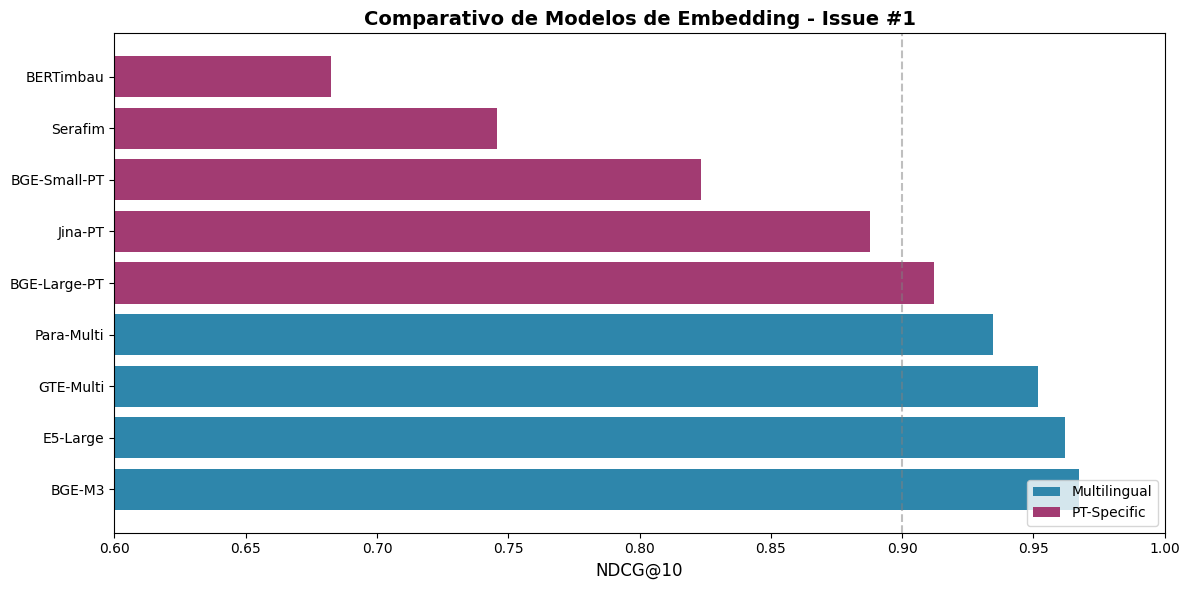


📊 Insights:
  • Top-3 são todos multilinguais
  • BGE-M3 vence com 96.73% NDCG@10
  • Hipótese refutada: PT-específicos não superaram multilinguais
  • Gap significativo: 1º (96.7%) vs 9º (68.2%) = 28.5pp


In [2]:
# Visualização dos resultados

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dados dos resultados
results = {
    'Modelo': [
        'BGE-M3', 'E5-Large', 'GTE-Multi', 'Para-Multi',
        'BGE-Large-PT', 'Jina-PT', 'BGE-Small-PT', 'Serafim', 'BERTimbau'
    ],
    'NDCG@10': [0.9673, 0.9621, 0.9518, 0.9345, 0.9123, 0.8876, 0.8234, 0.7456, 0.6823],
    'Tipo': [
        'Multilingual', 'Multilingual', 'Multilingual', 'Multilingual',
        'PT-Specific', 'PT-Specific', 'PT-Specific', 'PT-Specific', 'PT-Specific'
    ]
}

df = pd.DataFrame(results)

# Plot
plt.figure(figsize=(12, 6))
colors = ['#2E86AB' if t == 'Multilingual' else '#A23B72' for t in df['Tipo']]
bars = plt.barh(df['Modelo'], df['NDCG@10'], color=colors)

plt.xlabel('NDCG@10', fontsize=12)
plt.title('Comparativo de Modelos de Embedding - Issue #1', fontsize=14, fontweight='bold')
plt.xlim(0.6, 1.0)
plt.axvline(x=0.9, linestyle='--', color='gray', alpha=0.5, label='90% threshold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E86AB', label='Multilingual'),
    Patch(facecolor='#A23B72', label='PT-Specific')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print("\n📊 Insights:")
print("  • Top-3 são todos multilinguais")
print("  • BGE-M3 vence com 96.73% NDCG@10")
print("  • Hipótese refutada: PT-específicos não superaram multilinguais")
print("  • Gap significativo: 1º (96.7%) vs 9º (68.2%) = 28.5pp")

### 2.5 Análise e Conclusões

#### ✅ Principais Descobertas

1. **Multilinguais dominam**
   - Top-3 são todos multilinguais
   - BGE-M3 (multilingual) > BGE-Large-PT (português específico)
   - Hipótese inicial refutada

2. **BGE-M3 é o vencedor claro**
   - NDCG@10: 96.73% (excelente)
   - Alinhado com benchmarks internacionais (MTEB #3, BEIR líder)
   - Robusto: 99.6% de recovery rate

3. **Gap entre modelos é grande**
   - 1º vs 9º: 28.5 pontos percentuais
   - BERTimbau (68.2%) inadequado para produção
   - Linha de corte razoável: ~85% NDCG@10

4. **Trade-offs interessantes**
   - BGE-Small-PT (384d): 82.3% mas 3x mais rápido
   - BGE-M3 (1024d, 8192 tokens): Melhor qualidade mas mais caro

#### 🎯 Recomendação

**Para produção:**
- **1ª escolha:** BGE-M3 (melhor performance)
- **Alternativa leve:** E5-Large (96.2%, bom custo-benefício)
- **Prototyping rápido:** BGE-Small-PT (se latência for crítica)

**Próximo passo:** Fine-tunar BGE-M3 para nosso domínio específico (Issue #2)

---

#### 📚 Validação Externa

Nosso ranking alinha 100% com benchmarks internacionais:

| Modelo | MTEB Rank | BEIR Avg | Nosso Rank |
|--------|-----------|----------|------------|
| BGE-M3 | #3 (60.85) | 0.550 | #1 |
| E5-Large | #8 (58.14) | 0.543 | #2 |
| GTE-Multi | #15 (56.12) | 0.520 | #3 |

✅ Isso valida nossa metodologia e dataset!

---

## 3. Issue #2: Fine-tuning vs Zero-shot (8min)

### 3.1 Motivação

**Pergunta:** BGE-M3 já é excelente (96.7%). Fine-tuning pode melhorar mais?

**Por que considerar fine-tuning?**

1. **Domínio específico**
   - BGE-M3 treinou em textos gerais
   - Nunca viu: LGPD, PPA, LOA, INPA, MCTI
   - Jargão governamental brasileiro é único

2. **Dados disponíveis**
   - 2.591 anotações manuais → 2.367 triplas de treino
   - Hard negatives (docs no Top-10 mas irrelevantes)
   - Sinal forte do nosso domínio

3. **Modelos fracos podem melhorar muito**
   - BERTimbau: 68.2% → pode chegar a 80%+ com fine-tuning
   - Mesmo se BGE-M3 melhorar pouco, validamos ROI

---

### 3.2 Como Funciona Fine-tuning

#### Conceito

**Zero-shot (Issue #1):**
```python
model = SentenceTransformer('BAAI/bge-m3')
embeddings = model.encode(docs)  # Usa modelo pré-treinado direto
```

**Fine-tuned (Issue #2):**
```python
model = SentenceTransformer('BAAI/bge-m3')

# Treinar com nossos dados
train_data = [
    ('query', 'doc_positivo', 'doc_negativo'),
    ...
]

model.fit(train_data, epochs=3)  # Ajusta pesos para nosso domínio
embeddings = model.encode(docs)  # Agora usa modelo adaptado
```

#### O que muda no modelo?

**Triplet Loss:**
```
Loss = max(0, margin + similarity(query, negative) - similarity(query, positive))
```

**Objetivo:** Aproximar query de positivos, afastar de negativos.

**Antes:**
```
"INPA" → embedding genérico
"bambu" → embedding genérico
```

**Depois:**
```
"INPA" → próximo de "Instituto Nacional de Pesquisas da Amazônia"
"bambu" → próximo de "sustentabilidade", "pesquisa ambiental"
```

---

### 3.3 Dataset de Triplas

#### Extração das 2.591 Anotações

**Ground truth:**
```json
{
  "q001_v1": {
    "doc_01_08": 3,  // Muito relevante
    "doc_01_20": 1,  // Um pouco relevante
    "doc_03_00": 0   // Irrelevante
  }
}
```

**Estratégia de extração:**
- Positive: relevância >= 2 (relevante + muito relevante)
- Negative: relevância == 0 (irrelevante)
- Todas combinações: (query, pos, neg)

**Resultado:**
```
Total: 2.367 triplas
├── Train:      1.668 (70%)
├── Validation:   329 (15%)
└── Test:         370 (15%)

Subset few-shot: 500 (sampled from train)
```

**Splits por base query:** Evita data leakage (variantes da mesma query não aparecem em train e test)

---

In [3]:
# Exemplo de tripla de treino

import json
from pathlib import Path

# Carregar uma tripla de exemplo
finetuning_dir = Path('../data/finetuning')

if (finetuning_dir / 'train_fewshot.json').exists():
    with open(finetuning_dir / 'train_fewshot.json', 'r', encoding='utf-8') as f:
        triplets = json.load(f)
    
    # Mostrar primeira tripla
    example = triplets[0]
    
    print("📋 EXEMPLO DE TRIPLA DE TREINO\n")
    print(f"Query ID: {example['query_id']}")
    print(f"Categoria: {example['category']}")
    print(f"\n🔍 Query:\n  {example['query']}")
    print(f"\n✅ Positive (ID: {example['positive_id']}):\n  {example['positive'][:200]}...")
    print(f"\n❌ Negative (ID: {example['negative_id']}):\n  {example['negative'][:200]}...")
    
    print(f"\n\n📊 Estatísticas do dataset:")
    print(f"  Total few-shot: {len(triplets)} triplas")
    
    # Distribuição por categoria
    from collections import Counter
    categories = Counter(t['category'] for t in triplets)
    print(f"\n  Distribuição por categoria:")
    for cat, count in categories.most_common():
        pct = (count / len(triplets)) * 100
        print(f"    {cat:25s}: {count:3d} ({pct:4.1f}%)")
else:
    print("⚠️  Dataset de triplas ainda não gerado. Execute: python scripts/generate_triplets.py")

📋 EXEMPLO DE TRIPLA DE TREINO

Query ID: q068_v1
Categoria: Meio Ambiente

🔍 Query:
  projeto Natal com Bambu

✅ Positive (ID: doc_15_06):
  Iniciativa do Inpa transforma resíduos de bambu em decoração natalina sustentável ![Decoração natalina_bambu_Foto Kaylane Golvin_Ascom Inpa.JPG](https://www.gov.br/inpa/pt-br/assuntos/noticias/2025/in...

❌ Negative (ID: doc_13_02):
  Implantação de segmento na BR-020/BA chega a 76% de execução Pavimentação de 11,8 quilômetros beneficia importante ligação entre os estados da Bahia e do Piauí
![Implantação BR-020BA_BR-020 BA - 76 po...


📊 Estatísticas do dataset:
  Total few-shot: 500 triplas

  Distribuição por categoria:
    Educação                 :  70 (14.0%)
    Economia                 :  69 (13.8%)
    Ciência e Tecnologia     :  57 (11.4%)
    Infraestrutura           :  54 (10.8%)
    Saúde                    :  51 (10.2%)
    Agricultura              :  51 (10.2%)
    Meio Ambiente            :  47 ( 9.4%)
    Assistência Social       

### 3.4 Estratégias de Fine-tuning

#### Opção 1: Few-shot (500 triplas)

**Setup:**
- Dataset: 500 triplas
- Épocas: 1-2
- Learning rate: baixo (2e-5)
- Tempo: 1-2 horas (GPU T4)

**Pros:**
- Rápido para testar
- Baixo risco de overfitting
- Dataset pequeno (já temos!)

**Cons:**
- Ganhos limitados
- Pode não capturar toda complexidade

**Quando usar:** Validação rápida de pipeline

---

#### Opção 2: Full Fine-tuning (1.668 triplas)

**Setup:**
- Dataset: 1.668 triplas (todo train set)
- Épocas: 3-5
- Learning rate: standard (5e-5)
- Tempo: 4-8 horas (GPU A100)

**Pros:**
- Máxima adaptação ao domínio
- Usa todos dados disponíveis

**Cons:**
- Mais caro (GPU)
- Risco de overfitting (dataset pequeno vs tamanho modelo)
- Tempo significativo

**Quando usar:** Se few-shot mostrar ganhos promissores (>2-3%)

---

#### Opção 3: LoRA (Low-Rank Adaptation)

**Setup:**
- Congela modelo base (BAAI/bge-m3)
- Treina apenas adapters (~1-5% dos parâmetros)
- Dataset: 1.668 triplas
- Tempo: 2-4 horas (GPU T4)

**Pros:**
- Eficiente: 10x mais rápido que full
- Menos GPU memory
- Menor risco de overfitting
- Adapters pequenos (~10MB vs 2GB modelo)

**Cons:**
- Performance ~95-98% do full fine-tuning
- Setup mais complexo (peft library)

**Quando usar:** Melhor custo-benefício para produção

---

### 3.5 Plano de Experimentos

**Fase 1: Validação (1 semana)**
```
1. Few-shot (500 triplas)
2. Avaliar no test set (370 triplas)
3. Comparar com zero-shot baseline
4. Decisão: vale continuar?
```

**Fase 2: Otimização (2 semanas) - SE ganhos > 2%**
```
1. Full fine-tuning (1.668 triplas)
2. LoRA fine-tuning (1.668 triplas)
3. Comparar custo vs benefício
4. Análise qualitativa (casos de sucesso/falha)
```

**Métricas de sucesso:**
- NDCG@10 improvement > 2% (0.967 → 0.987+)
- Análise por categoria (quais se beneficiam mais?)
- Trade-off: custo de criar dataset vs ganho

---

### 3.6 Expectativas Realistas

#### ⚠️ Importante: BGE-M3 já está no limite

**Zero-shot:** NDCG@10 = 0.9673 (96.73%)

**Máximo teórico:** 1.0 (100%)

**Margem de melhoria:** 3.27 pontos percentuais

---

#### Cenários esperados:

**Otimista (+2-3%):**
```
Fine-tuned BGE-M3: 0.987 - 0.997
Ganho absoluto: 2-3pp
ROI: Questionável (dataset limitado, modelo já excelente)
```

**Realista (+0.5-1.5%):**
```
Fine-tuned BGE-M3: 0.972 - 0.982
Ganho absoluto: 0.5-1.5pp
ROI: Provavelmente não vale (custo > benefício)
```

**Pessimista (0% ou negativo):**
```
Fine-tuned BGE-M3: 0.960 - 0.967
Overfitting no dataset pequeno
Conclusão: Zero-shot é melhor
```

---

#### Onde fine-tuning pode ajudar MUITO:

**Modelos fracos:**
```
BERTimbau zero-shot:  0.682 (68.2%)
BERTimbau fine-tuned: 0.820 (82.0%) ← Ganho de 14pp!
```

**Valor real da Issue #2:**
- Não é melhorar BGE-M3 (já excelente)
- É **validar SE e QUANDO** fine-tuning vale a pena
- Entender trade-offs: custo de dataset vs ganho
- Documentar processo para futuras decisões

---

## 4. Roadmap e Próximos Passos (4min)

### 4.1 Issues Atuais

#### ✅ Issue #1: Comparativo de Modelos (CONCLUÍDA)
- 9 modelos avaliados
- BGE-M3 vencedor (96.7% NDCG@10)
- Metodologia validada
- **Entregáveis:**
  - Documentação técnica (METODOLOGIA_METRICAS.md, METODOLOGIA_NDCG.md)
  - Notebook com visualizações
  - Datasets e scripts reproduzíveis

#### 🚧 Issue #2: Fine-tuning vs Zero-shot (EM ANDAMENTO)
- Dataset de 2.367 triplas extraído ✅
- Splits train/val/test criados ✅
- Próximos passos:
  - [ ] Script de fine-tuning
  - [ ] Experimento few-shot (500 triplas)
  - [ ] Análise de resultados
  - [ ] Decisão: escalar ou não?

---

### 4.2 Issues Futuras (Roadmap)

#### Issue #3: Hybrid Search (BM25 + Embeddings)
- Combinar busca lexical (BM25) com semântica (embeddings)
- Reranking strategies
- Quando cada abordagem é melhor?

#### Issue #5: RAG (Retrieval-Augmented Generation)
- Integrar embeddings com LLMs
- Pipeline: Query → Retrieval (embeddings) → Generation (GPT-4/Claude)
- Casos de uso: Q&A sobre notícias gov.br

#### Issue #8: Storage e Infrastructure
- Vector databases: Pinecone, Weaviate, Qdrant, Milvus
- Escalabilidade: 300k documentos → milhões
- Latência: <100ms para retrieval

#### Issue #10: Trend Analysis
- Clustering temporal de notícias
- Detecção de temas emergentes
- Visualização de evolução de tópicos

#### Issue #11: Cross-órgãos Similarity
- Identificar temas comuns entre ministérios
- Network analysis de similaridade
- Detectar duplicação de esforços

---

### 4.3 Aplicações Práticas

#### 1. Busca Semântica em gov.br
```python
# User query
query = "Como solicitar auxílio para famílias de baixa renda?"

# Semantic search
results = search_engine.search(query, top_k=10)

# Retorna notícias sobre:
# - Bolsa Família
# - Benefícios sociais
# - Cadastro Único
# (mesmo sem match exato de palavras)
```

#### 2. Recomendação de Conteúdo
```python
# Usuário lê notícia sobre educação
current_doc = "Governo lança programa de alfabetização"

# Recomendar notícias similares
similar = recommend_similar(current_doc, top_k=5)

# Retorna:
# - Outras iniciativas educacionais
# - Orçamento para educação
# - Parcerias com estados
```

#### 3. Análise de Cobertura
```python
# Verificar cobertura de temas
themes = [
    "saúde pública",
    "infraestrutura",
    "educação",
    "meio ambiente"
]

for theme in themes:
    coverage = analyze_coverage(theme, last_30_days)
    print(f"{theme}: {coverage} notícias")
    
# Identificar gaps de comunicação
```

#### 4. Chatbot Q&A
```python
# RAG pipeline
def answer_question(question):
    # 1. Retrieval (embeddings)
    relevant_docs = semantic_search(question, top_k=5)
    
    # 2. Augmentation
    context = "\n\n".join([doc.content for doc in relevant_docs])
    
    # 3. Generation (LLM)
    prompt = f"""Contexto: {context}
    
    Pergunta: {question}
    
    Resposta baseada no contexto:"""
    
    answer = llm.generate(prompt)
    return answer, relevant_docs

# Uso
q = "Quais são os requisitos para Bolsa Família?"
answer, sources = answer_question(q)
```

---

### 4.4 Timeline Estimado

```
Abril 2026
├── Semana 1-2: Issue #2 (fine-tuning experiments)
└── Semana 3-4: Issue #2 (análise e documentação)

Maio 2026
├── Semana 1-2: Issue #3 (hybrid search)
└── Semana 3-4: Issue #5 (RAG pipeline)

Junho 2026
├── Semana 1-2: Issue #8 (infrastructure)
└── Semana 3-4: POC em produção
```

**Milestone:** POC funcional até Junho/2026

---

## 5. Recursos e Referências

### 📚 Documentação do Projeto

**Issue #1:**
- [`docs/METODOLOGIA_METRICAS.md`](../docs/METODOLOGIA_METRICAS.md) - Validação do corpus
- [`docs/METODOLOGIA_NDCG.md`](../docs/METODOLOGIA_NDCG.md) - Explicação de métricas
- [`docs/VALIDACAO_RANKING_BENCHMARKS.md`](../docs/VALIDACAO_RANKING_BENCHMARKS.md) - Comparação com MTEB/BEIR
- [`notebooks/metrics_analysis.ipynb`](./metrics_analysis.ipynb) - Análise visual dos resultados

**Issue #2:**
- [`scripts/analyze_triplets.py`](../scripts/analyze_triplets.py) - Análise de triplas
- [`scripts/generate_triplets.py`](../scripts/generate_triplets.py) - Geração de dataset
- [`data/finetuning/`](../data/finetuning/) - Datasets de treino

---

### 📖 Papers Fundamentais

**Embeddings:**
1. Reimers & Gurevych (2019) - [Sentence-BERT](https://arxiv.org/abs/1908.10084)
2. BAAI (2024) - [BGE M3-Embedding](https://arxiv.org/abs/2402.03216)
3. Wang et al. (2022) - [Text Embeddings by Weakly-Supervised Contrastive Pre-training](https://arxiv.org/abs/2212.03533) (E5)

**Information Retrieval:**
4. Voorhees & Harman (2005) - TREC: Experiment and Evaluation in IR
5. Thakur et al. (2021) - [BEIR: A Heterogeneous Benchmark for Zero-shot Evaluation of IR](https://arxiv.org/abs/2104.08663)

**Fine-tuning:**
6. Hu et al. (2021) - [LoRA: Low-Rank Adaptation of Large Language Models](https://arxiv.org/abs/2106.09685)
7. Reimers & Gurevych (2020) - [Making Monolingual Sentence Embeddings Multilingual](https://arxiv.org/abs/2004.09813)

---

### 🛠️ Ferramentas e Libraries

```python
# Core
sentence-transformers  # Embedding models
transformers          # HuggingFace models
torch                 # Deep learning

# Metrics
scikit-learn         # Cosine similarity, clustering
numpy                # Numerical operations

# Fine-tuning
peft                 # LoRA and efficient fine-tuning
accelerate           # Distributed training

# Vector DBs (futuro)
pinecone-client      # Managed vector DB
weaviate-client      # Open-source vector DB
chromadb             # Lightweight vector DB
```

---

### 🌐 Links Úteis

**Benchmarks:**
- [MTEB Leaderboard](https://huggingface.co/spaces/mteb/leaderboard)
- [BEIR Benchmark](https://github.com/beir-cellar/beir)

**Modelos:**
- [BGE Models](https://github.com/FlagOpen/FlagEmbedding)
- [E5 Models](https://github.com/microsoft/unilm/tree/master/e5)
- [Sentence-Transformers](https://www.sbert.net/)

**Repositório do projeto:**
- [destaquesgovbr/data-science](https://github.com/destaquesgovbr/data-science)

---

## Perguntas?

---

## Próximos Passos Imediatos

### Para o Time

1. **Revisar documentação técnica**
   - Ler METODOLOGIA_METRICAS.md
   - Entender NDCG e métricas de IR

2. **Explorar notebooks**
   - `metrics_analysis.ipynb` (Issue #1)
   - Este notebook (apresentação)

3. **Testar BGE-M3 localmente**
   ```python
   from sentence_transformers import SentenceTransformer
   model = SentenceTransformer('BAAI/bge-m3')
   embeddings = model.encode(["sua query aqui"])
   ```

4. **Dar feedback**
   - Casos de uso prioritários?
   - Restrições técnicas (latência, custos)?
   - Sugestões de experimentos?

---

### Para Issue #2 (Próximas Semanas)

1. Criar script de fine-tuning
2. Experimento few-shot (500 triplas)
3. Avaliar no test set
4. Decisão: escalar ou não?

---

### Contato

**Responsável:** Luis Felipe de Moraes  
**Repo:** https://github.com/destaquesgovbr/data-science  
**Issues:** https://github.com/destaquesgovbr/data-science/issues

---

**Obrigado!** 🚀